# **Step 1: Load and Understand the Dataset**

In [81]:
import pandas as pd

df = pd.read_csv("data/spam.csv" , encoding="latin-1")
df.head(10)
df.columns
df.shape

# As Last 3 columns are useless
df = df[['v1' , 'v2']]

# Renaming columns accordingly
df.columns = ['label' , 'message']

df.head()

# Missing Value sum
print(df.isnull().sum())


label      0
message    0
dtype: int64


In [82]:
# Class Distribution
x = df["label"].value_counts()
print(x)

# Calculating Prior (Belief before getting any evidence)
p_spam = round(x['spam'] / (x['spam'] + x['ham']), 4)
p_ham  = round(x['ham'] / (x['spam'] + x['ham']), 4)

print(p_spam)
print(p_ham)


label
ham     4825
spam     747
Name: count, dtype: int64
0.1341
0.8659


# **Step 2: Text Cleaning & Preprocessing**

In [83]:
# Converting text labels to value 0 and 1
df["label"] = df["label"].map({
    "ham": "0",
    "spam": "1"
})
df.head()
df["label"] = df["label"].astype("int64")
df["label"].unique()

# Converting the messages to lowercase for processing further
df["message"] = df["message"].str.lower()
df.head()

# Removing punctuation
import re
df["message"] = df["message"].apply(
    lambda x : re.sub(r"[^\w\s]" , "" , x)
)
df.head()

# Creating Tokens for classification
df["tokens"] = df["message"].apply(
    lambda x: x.split()
)

df.head()

,label,message,tokens
0,0,go until jurong point crazy available only in ...,"[go, until, jurong, point, crazy, available, o..."
1,0,ok lar joking wif u oni,"[ok, lar, joking, wif, u, oni]"
2,1,free entry in 2 a wkly comp to win fa cup fina...,"[free, entry, in, 2, a, wkly, comp, to, win, f..."
3,0,u dun say so early hor u c already then say,"[u, dun, say, so, early, hor, u, c, already, t..."
4,0,nah i dont think he goes to usf he lives aroun...,"[nah, i, dont, think, he, goes, to, usf, he, l..."


* import re
*
* df["message"] = df["message"].apply(
*     lambda x: re.sub(r"[^\w\s]", "", x)
* )
*

```
* df["message"] → selects the message column.
* .apply() → runs a function on every message.
* lambda x: → anonymous function where x is one message.
* re.sub(pattern, replacement, string) → replaces matching text.
* r"[^\w\s]" →
* \w = letters, digits, _
* \s = whitespace
* ^ = NOT
* So it matches any character that is not a letter, digit, underscore, or space.
* "" → replace matches with nothing (delete them).
```

In [84]:
df["label"].unique()


array([0, 1])

# **Step 3: Build Vocabulary & Count Words**

* Messages
*     ↓
* Tokens
*     ↓
* Count Words
*     ↓
* Calculate Likelihoods

**What is Vocabulary?**

**`Vocabulary = all unique words in the dataset.**
`

Example:

Messages:

* free money now
* free offer
* project meeting

Vocabulary:

* free
* money
* now
* offer
* project
* meeting

In [85]:
# Creating Vocabulary

vocabulary = set()

for tokens in df["tokens"]:
    vocabulary.update(tokens)  # .update add all elements from an iterable to set
print(len(vocabulary))


## For Spam


# Counting the word count for spam
spam_df = df[df["label"] == 1]

from collections import  Counter

spam_words = []
for tokens in spam_df["tokens"]:
    spam_words.extend(tokens)

spam_word_counts = Counter(spam_words) # Counter counts how many times each item appears in an iterable.

spam_word_counts.most_common(10) # return highest count words




# For Ham

ham_df = df[df["label"] == 0]
ham_words = []

for tokens in ham_df["tokens"]:
    ham_words.extend(tokens)

ham_word_counts = Counter(ham_words)
ham_word_counts.most_common(10)


9564


[('i', 2185),
 ('you', 1837),
 ('to', 1554),
 ('the', 1118),
 ('a', 1052),
 ('u', 972),
 ('and', 848),
 ('in', 811),
 ('me', 756),
 ('my', 743)]

In [86]:
# Total Words
# Needed later for likelihoods.

total_spam_words = sum(
    spam_word_counts.values()
)

total_ham_words = sum(
    ham_word_counts.values()
)

# **Step 4: Calculate Likelihoods**

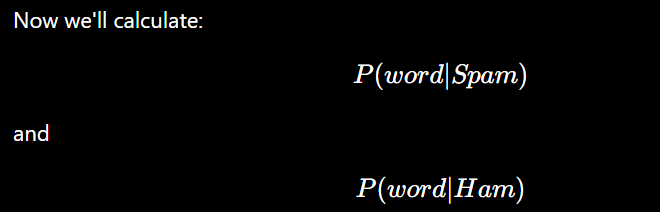

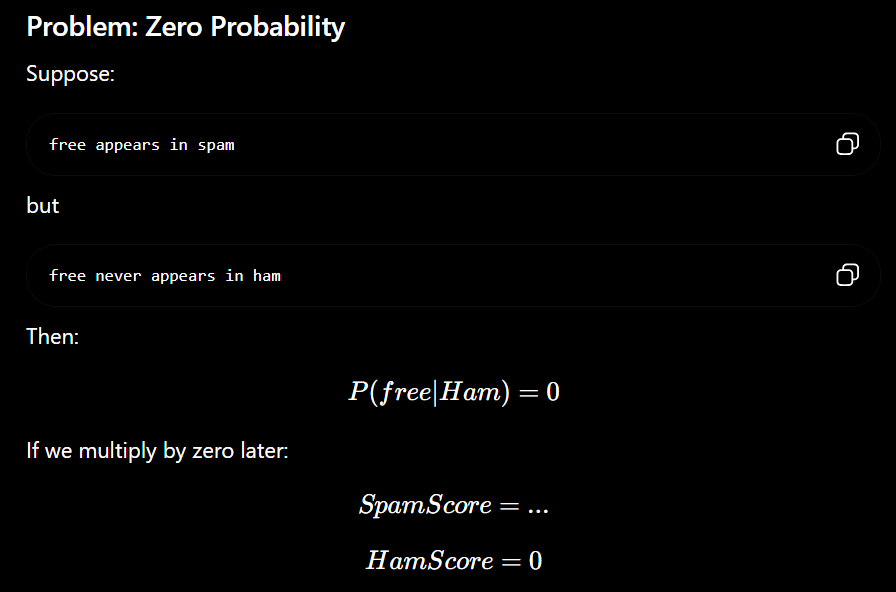

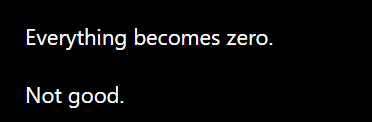

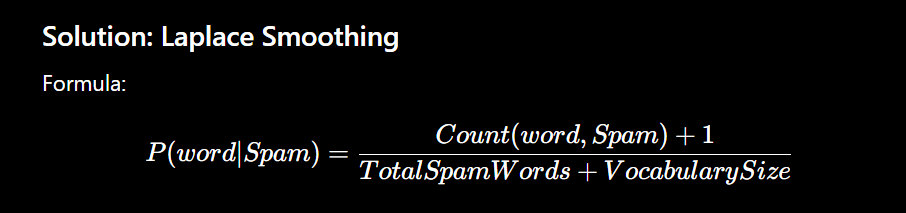



In [87]:
# Vocabulary size
vocab_size = len(vocabulary)

# Spam word Likelihood function
def likelihood_spam(word):

    return (
            spam_word_counts[word] + 1
    ) / (
            total_spam_words + vocab_size
    )

# Ham word Likelihood function
def likelihood_ham(word):

    return (
            ham_word_counts[word] + 1
    ) / (
            total_ham_words + vocab_size
    )

print(
    likelihood_spam("free")
)

print(
    likelihood_ham("free")
)
print(likelihood_spam("supercar"))

0.00799027910744532
0.0007783716465154896
3.682156270712129e-05


# **Step 5: Calculate Spam Score & Ham Score**

This score is essentially answering:

**`How likely is this entire message
if it came from the Spam class?`**

and

**`How likely is this entire message
if it came from the Ham class?`**

**Example:**
**`free money now`**

**Spam score:**
**`P(Spam)×P(free∣Spam)×P(money∣Spam)×P(now∣Spam)`**

**This means:**
**`If the message were Spam,
how likely would we be to see
these words together?`**

In [88]:
# Just an Example

message = "free money now"

message_tokens = message.lower().split()

spam_score = p_spam
ham_score = p_ham

for word in message_tokens:
    spam_score *= likelihood_spam(word)
    ham_score *= likelihood_ham(word)

print("Spam Score:", spam_score)
print("Ham Score:", ham_score)

if spam_score > ham_score:
    print("Spam")
else:
    print("Ham")

Spam Score: 1.3801260873092324e-09
Ham Score: 1.7763069684524017e-09
Ham


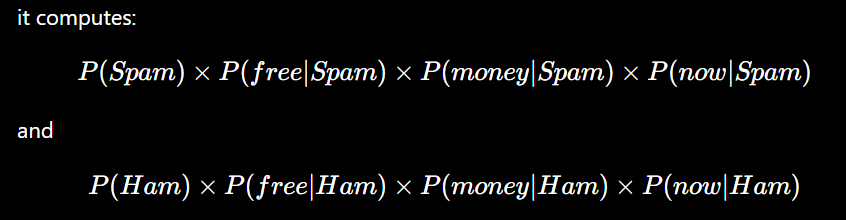

In [ ]:
def predict(message):

    tokens = message.lower().split()

    spam_score = p_spam
    ham_score = p_ham

    for word in tokens:
        spam_score *= likelihood_spam(word)
        ham_score *= likelihood_ham(word)

    if spam_score > ham_score:
        return "Spam"

    return "Ham"

# Naive Independence Assumption

This is why the algorithm is called **Naive Bayes**.

---

## The Assumption

Naive Bayes assumes:

```text id="t2hn87"
All words are independent
given the class.
```

---

## Example

Message:

```text id="x7ezhe"
free money now
```

Actual probability:

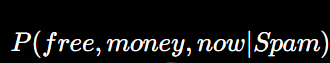

This is hard to calculate.

---

## Naive Assumption

We pretend:

```text id="rq5qpg"
free is independent of money

money is independent of now

free is independent of now
```

Then:

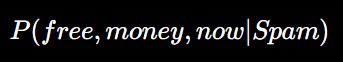

becomes:

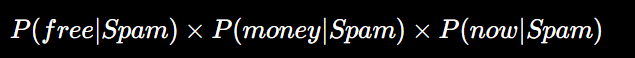
---

## Why Do This?

Because:

```text id="e6k3a9"
Calculating joint probabilities
for millions of word combinations
is impossible.
```

Multiplying individual probabilities is much easier.

---

## Is It True?

Not really.

Example:

```text id="33pwn6"
New York
```

Words are clearly related.

```text id="lk8r3g"
credit card
```

Words are related.

So the assumption is often false.

---

## Then Why Does It Work?

Even with a wrong assumption:

```text id="smpt9r"
Naive Bayes often gives
surprisingly good results.
```

Especially for:

```text id="sdxg5d"
Spam Detection

Text Classification

Document Classification
```

---

## What To Remember

```text id="m4zckw"
Real World:
Words are related

Naive Bayes:
Pretends they are independent
```

so it can compute:

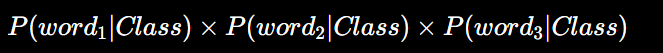

instead of a huge complicated probability.

---

## **Limitations**

* Doesn't understand meaning
*
* Only uses word frequencies
*
* Assumes word independence
*
* Very simple model


## **We have used BAYES Theorem here  but without the evidence we compared only numerators**

What we coded is actually a **simplified Naive Bayes**.

The full Bayes formula is:

For spam detection:

![image.png](attachment:87ebfc7a-bb8b-468c-a434-b7e6d15b3855.png)

where:

```text id="7tyrgt"
P(Spam)
= Prior

P(Message|Spam)
= Likelihood

P(Message)
= Evidence

P(Spam|Message)
= Posterior
```

---

But in our code we computed:

![image.png](attachment:56172d8e-c827-4793-9cef-b91a83b43026.png)

and compared them.

---

Why did we skip Evidence?

Because:

**`P(Message)`**

is the same for both classes.

Example:

```text id="4uqn9k"
Message = "free money now"
```

The evidence:

**`P(Message)`**

has one value regardless of whether we're checking Spam or Ham.

So:

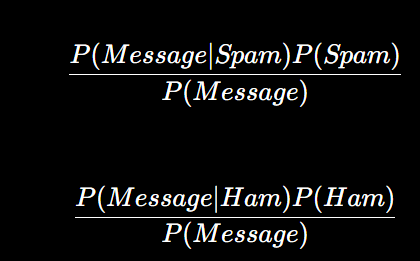

have the same denominator.

When comparing two fractions with the same denominator, we can ignore it.

Example:

```text id="nlv4n3"
8/100

vs

3/100
```

You don't need `/100` to know 8 is larger.

---

So our code really computes:

```text id="c7m6aa"
Posterior ∝ Likelihood × Prior
```

(not exactly equal, but proportional).

That's why Naive Bayes implementations usually don't explicitly calculate Evidence.

---

So your understanding is correct:

```text id="v7aqxt"
We never explicitly calculated

P(Spam|Message)

because

P(Message)

was ignored.
```

For spam project:

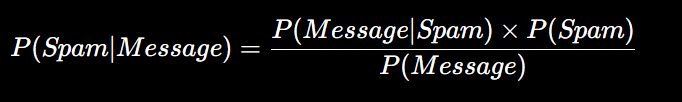
---

### 1. Prior

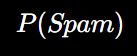

Meaning:

```text id="7n3g0x"
How common is Spam
in the training dataset?
```

Computed as:

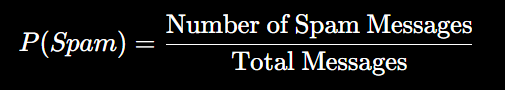

Example:

```text id="i08n9u"
Spam = 747

Total = 5572
```

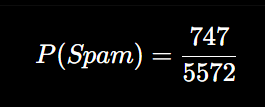

---

### 2. Likelihood

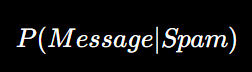

Meaning:

```text id="c38m8u"
If the message is Spam,
how likely are these words?
```

For:

```text id="4guzhx"
free money now
```

Naive Bayes assumes independence:

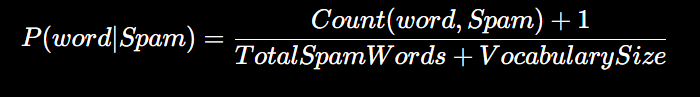

---

### 3. Evidence

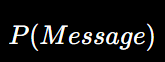

Meaning:

```text id="0s3zcx"
How common is this message
in the whole dataset?
```

For:

```text id="2iwq6x"
free money now
```

it would be:

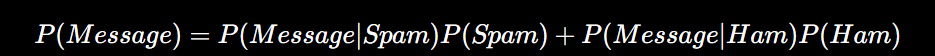
---

### 4. Posterior

[
P(Spam|Message)
]

Meaning:

```text id="i4gxz7"
Given this message,
what is the probability
it is Spam?
```

This is the final answer Bayes gives.

---

### What We Actually Computed

We computed:

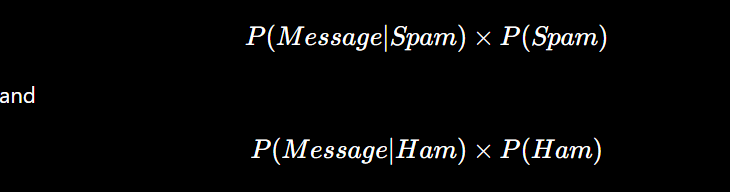
Then compared them.

```text id="jw75cv"
Spam Score

vs

Ham Score
```

Because the Evidence term is identical for both classes.